# RR1/RR3 contextual-graph case study

## Why this case study exists

This notebook asks whether retaining **gene-resolved contextual organization** can distinguish true technical remeasurements from a misleading similarity created by globally averaging all 15,165 gene tokens.

The method was fixed independently of RR1/RR3: frozen layer-12 contextual embeddings, directed cosine kNN per gene, `k=10`, then union symmetrization. No BridgeRNA inference, graph tuning, or model training occurs here. RR1/RR3 are held-out stress cases.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if not (ROOT / 'results').exists():
    ROOT = ROOT / 'benchmarks/rr1_rr3_contextual_graph_case_study'
RESULTS = ROOT / 'results'
pd.set_option('display.max_colwidth', 100)
summary = json.loads((RESULTS / 'case_study_summary.json').read_text())

## Cohort and comparison definitions

- **RR1:** OSD-48 RR1-NASA 37-day response versus its OSD-168 technical remeasurement.
- **RR3-39:** OSD-137 RR3 39-day response versus its OSD-168 technical remeasurement.
- **RR3-40:** OSD-137 RR3 40-day response versus its OSD-168 technical remeasurement.
- **False friend:** RR1 original response versus the biologically unrelated RR3-39 original response.

Every response is `mean(FLT) - mean(GC)`. Technical remeasurements are repeated material, not independent biological replication.

In [2]:
manifest = pd.read_csv(RESULTS / 'sample_manifest.csv')
cohort = (manifest.groupby(['measurement', 'contrast_id', 'OSD', 'condition'])
          .agg(n=('sample_id', 'size'), sample_ids=('sample_id', lambda x: ', '.join(x)))
          .reset_index())
display(cohort)

,measurement,contrast_id,OSD,condition,n,sample_ids
0,RR1_original,C14__OSD-48__RR1-NASA__37-day,OSD-48,FLT,4,"Mmus_C57-6J_LVR_FLT_C_Rep1_M25, Mmus_C57-6J_LVR_FLT_C_Rep2_M26, Mmus_C57-6J_LVR_FLT_C_Rep4_M28, ..."
1,RR1_original,C14__OSD-48__RR1-NASA__37-day,OSD-48,GC,5,"Mmus_C57-6J_LVR_GC_C_Rep1_M36, Mmus_C57-6J_LVR_GC_C_Rep2_M37, Mmus_C57-6J_LVR_GC_C_Rep3_M38, Mmu..."
2,RR1_remeasurement,C04__OSD-168__RR1-NASA__37-day,OSD-168,FLT,8,"Mmus_C57-6J_LVR_RR1_FLT_noERCC_Rep1_M25, Mmus_C57-6J_LVR_RR1_FLT_noERCC_Rep2_M26, Mmus_C57-6J_LV..."
3,RR1_remeasurement,C04__OSD-168__RR1-NASA__37-day,OSD-168,GC,10,"Mmus_C57-6J_LVR_RR1_GC_noERCC_Rep1_M36, Mmus_C57-6J_LVR_RR1_GC_noERCC_Rep2_M37, Mmus_C57-6J_LVR_..."
4,RR3_39_original,C01__OSD-137__RR3__39-day,OSD-137,FLT,2,"Mmus_BAL-TAL_LVR_FLT_Rep1_F1, Mmus_BAL-TAL_LVR_FLT_Rep2_F2"
5,RR3_39_original,C01__OSD-137__RR3__39-day,OSD-137,GC,2,"Mmus_BAL-TAL_LVR_GC_Rep1_G1, Mmus_BAL-TAL_LVR_GC_Rep2_G2"
6,RR3_39_remeasurement,C05__OSD-168__RR3__39-day,OSD-168,FLT,2,"Mmus_BAL-TAL_LVR_RR3_FLT_wERCC_Rep1_F1, Mmus_BAL-TAL_LVR_RR3_FLT_wERCC_Rep2_F2"
7,RR3_39_remeasurement,C05__OSD-168__RR3__39-day,OSD-168,GC,2,"Mmus_BAL-TAL_LVR_RR3_GC_wERCC_Rep1_G1, Mmus_BAL-TAL_LVR_RR3_GC_wERCC_Rep2_G2"
8,RR3_40_original,C02__OSD-137__RR3__40-day,OSD-137,FLT,2,"Mmus_BAL-TAL_LVR_FLT_Rep3_F3, Mmus_BAL-TAL_LVR_FLT_Rep4_F4"
9,RR3_40_original,C02__OSD-137__RR3__40-day,OSD-137,GC,2,"Mmus_BAL-TAL_LVR_GC_Rep3_G3, Mmus_BAL-TAL_LVR_GC_Rep4_G5"


## The pooling failure and the graph result

Global mean pooling collapses 15,165 contextual gene embeddings into a single 512-D vector. It can therefore make two responses similar while discarding *which genes have which contextual neighborhoods*.

The graph readout keeps every canonical gene as a fixed node. For each sample, an edge connects a gene to its most similar contextual-gene neighbors. Study responses are signed changes in these weighted edges (`FLT - GC`). We compare true replicate response graphs with the unrelated false-friend pair.

Because vector cosine and graph similarity have different scales, the valid comparison is **ordering/discrimination within each representation**, not raw score magnitude across representations.

representation,Bridge mean,Graph signed-edge response
comparison,,
RR1,-0.807,0.183
RR1↔RR3-39 false friend,0.811,0.012
RR3-39,0.790,0.319
RR3-40,0.917,0.399


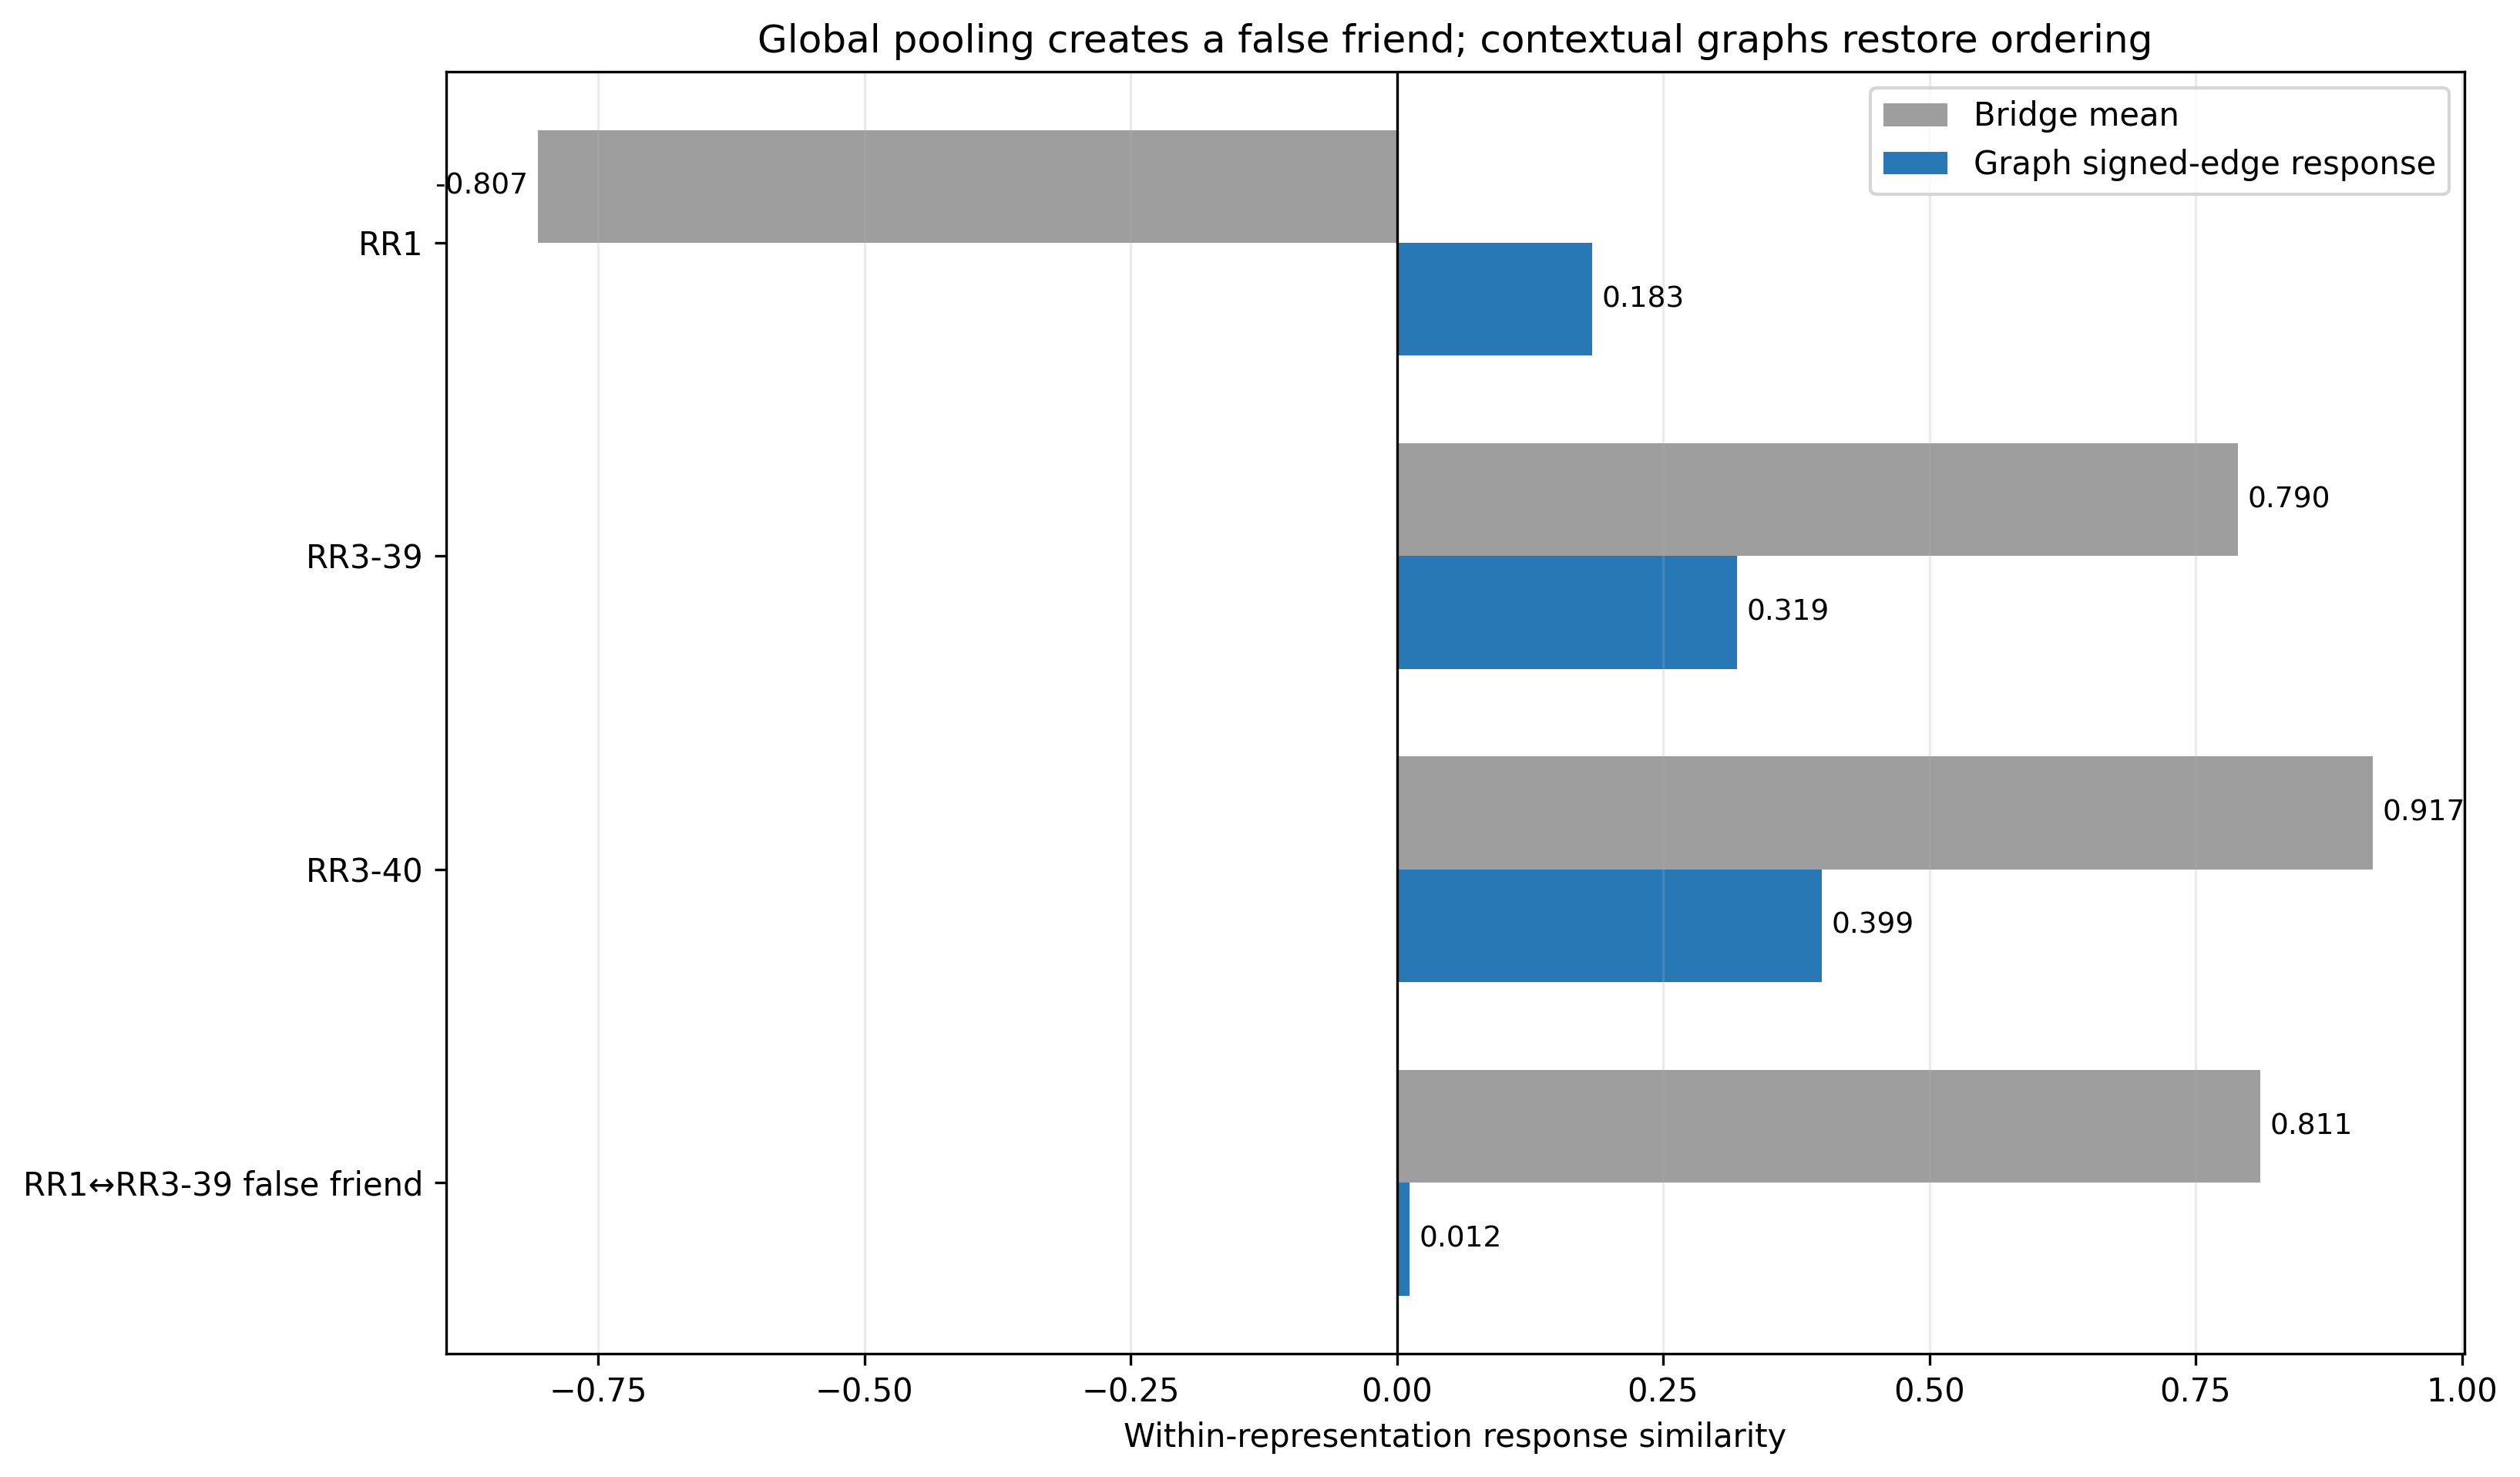

In [3]:
scores = pd.read_csv(RESULTS / 'global_mean_vs_graph.csv')
wide = scores.pivot(index='comparison', columns='representation', values='similarity')
display(wide.style.format('{:.3f}'))
display(Image(filename=str(RESULTS / 'figures/global_mean_vs_graph.png')))

### Main result

With global BridgeRNA mean pooling, the unrelated RR1↔RR3-39 pair scores **0.811**, slightly higher than the true RR3-39 remeasurement (**0.790**). This is the global-embedding false friend.

With the prespecified contextual graph, RR3-39 (**0.319**) and RR3-40 (**0.399**) both rank well above the false friend (**0.012**). The graph therefore recovers the correct relationship ordering. RR1 remains poorly reproducible (**0.183**) and is not presented as rescued.

This is evidence that gene-resolved contextual organization contains useful structure lost by a single global mean. It is not evidence that graph edges are causal or regulatory interactions.

## Which gene neighborhoods distinguish true replication?

For each fixed gene, we compare its signed neighborhood-change profile between the two RR3 measurements. The diagnostic score is the mean true-replicate local cosine minus the RR1↔RR3-39 false-friend local cosine. This localization is descriptive; it did not define or tune the graph.

,gene_symbol,rr3_39_true_local_cosine,rr3_40_true_local_cosine,false_friend_local_cosine,rr3_39_discrimination,rr3_40_discrimination,mean_true_discrimination,rank
0,FGF20,1.000,1.000,-0.976,1.976,1.976,1.976,1
1,HOXB5,0.865,0.772,-0.737,1.602,1.509,1.556,2
2,SOX14,0.664,0.793,-0.819,1.484,1.612,1.548,3
3,ADAM7,0.833,0.707,-0.761,1.594,1.468,1.531,4
4,SARS2,0.948,0.401,-0.810,1.758,1.211,1.484,5
5,COL5A1,1.000,0.744,-0.575,1.575,1.319,1.447,6
6,G3BP1,0.748,1.000,-0.569,1.317,1.569,1.443,7
7,ATP6V1E1,0.871,0.720,-0.624,1.495,1.344,1.419,8
8,CDC73,1.000,0.871,-0.480,1.480,1.351,1.415,9
9,RPL19,0.817,0.708,-0.643,1.460,1.351,1.405,10


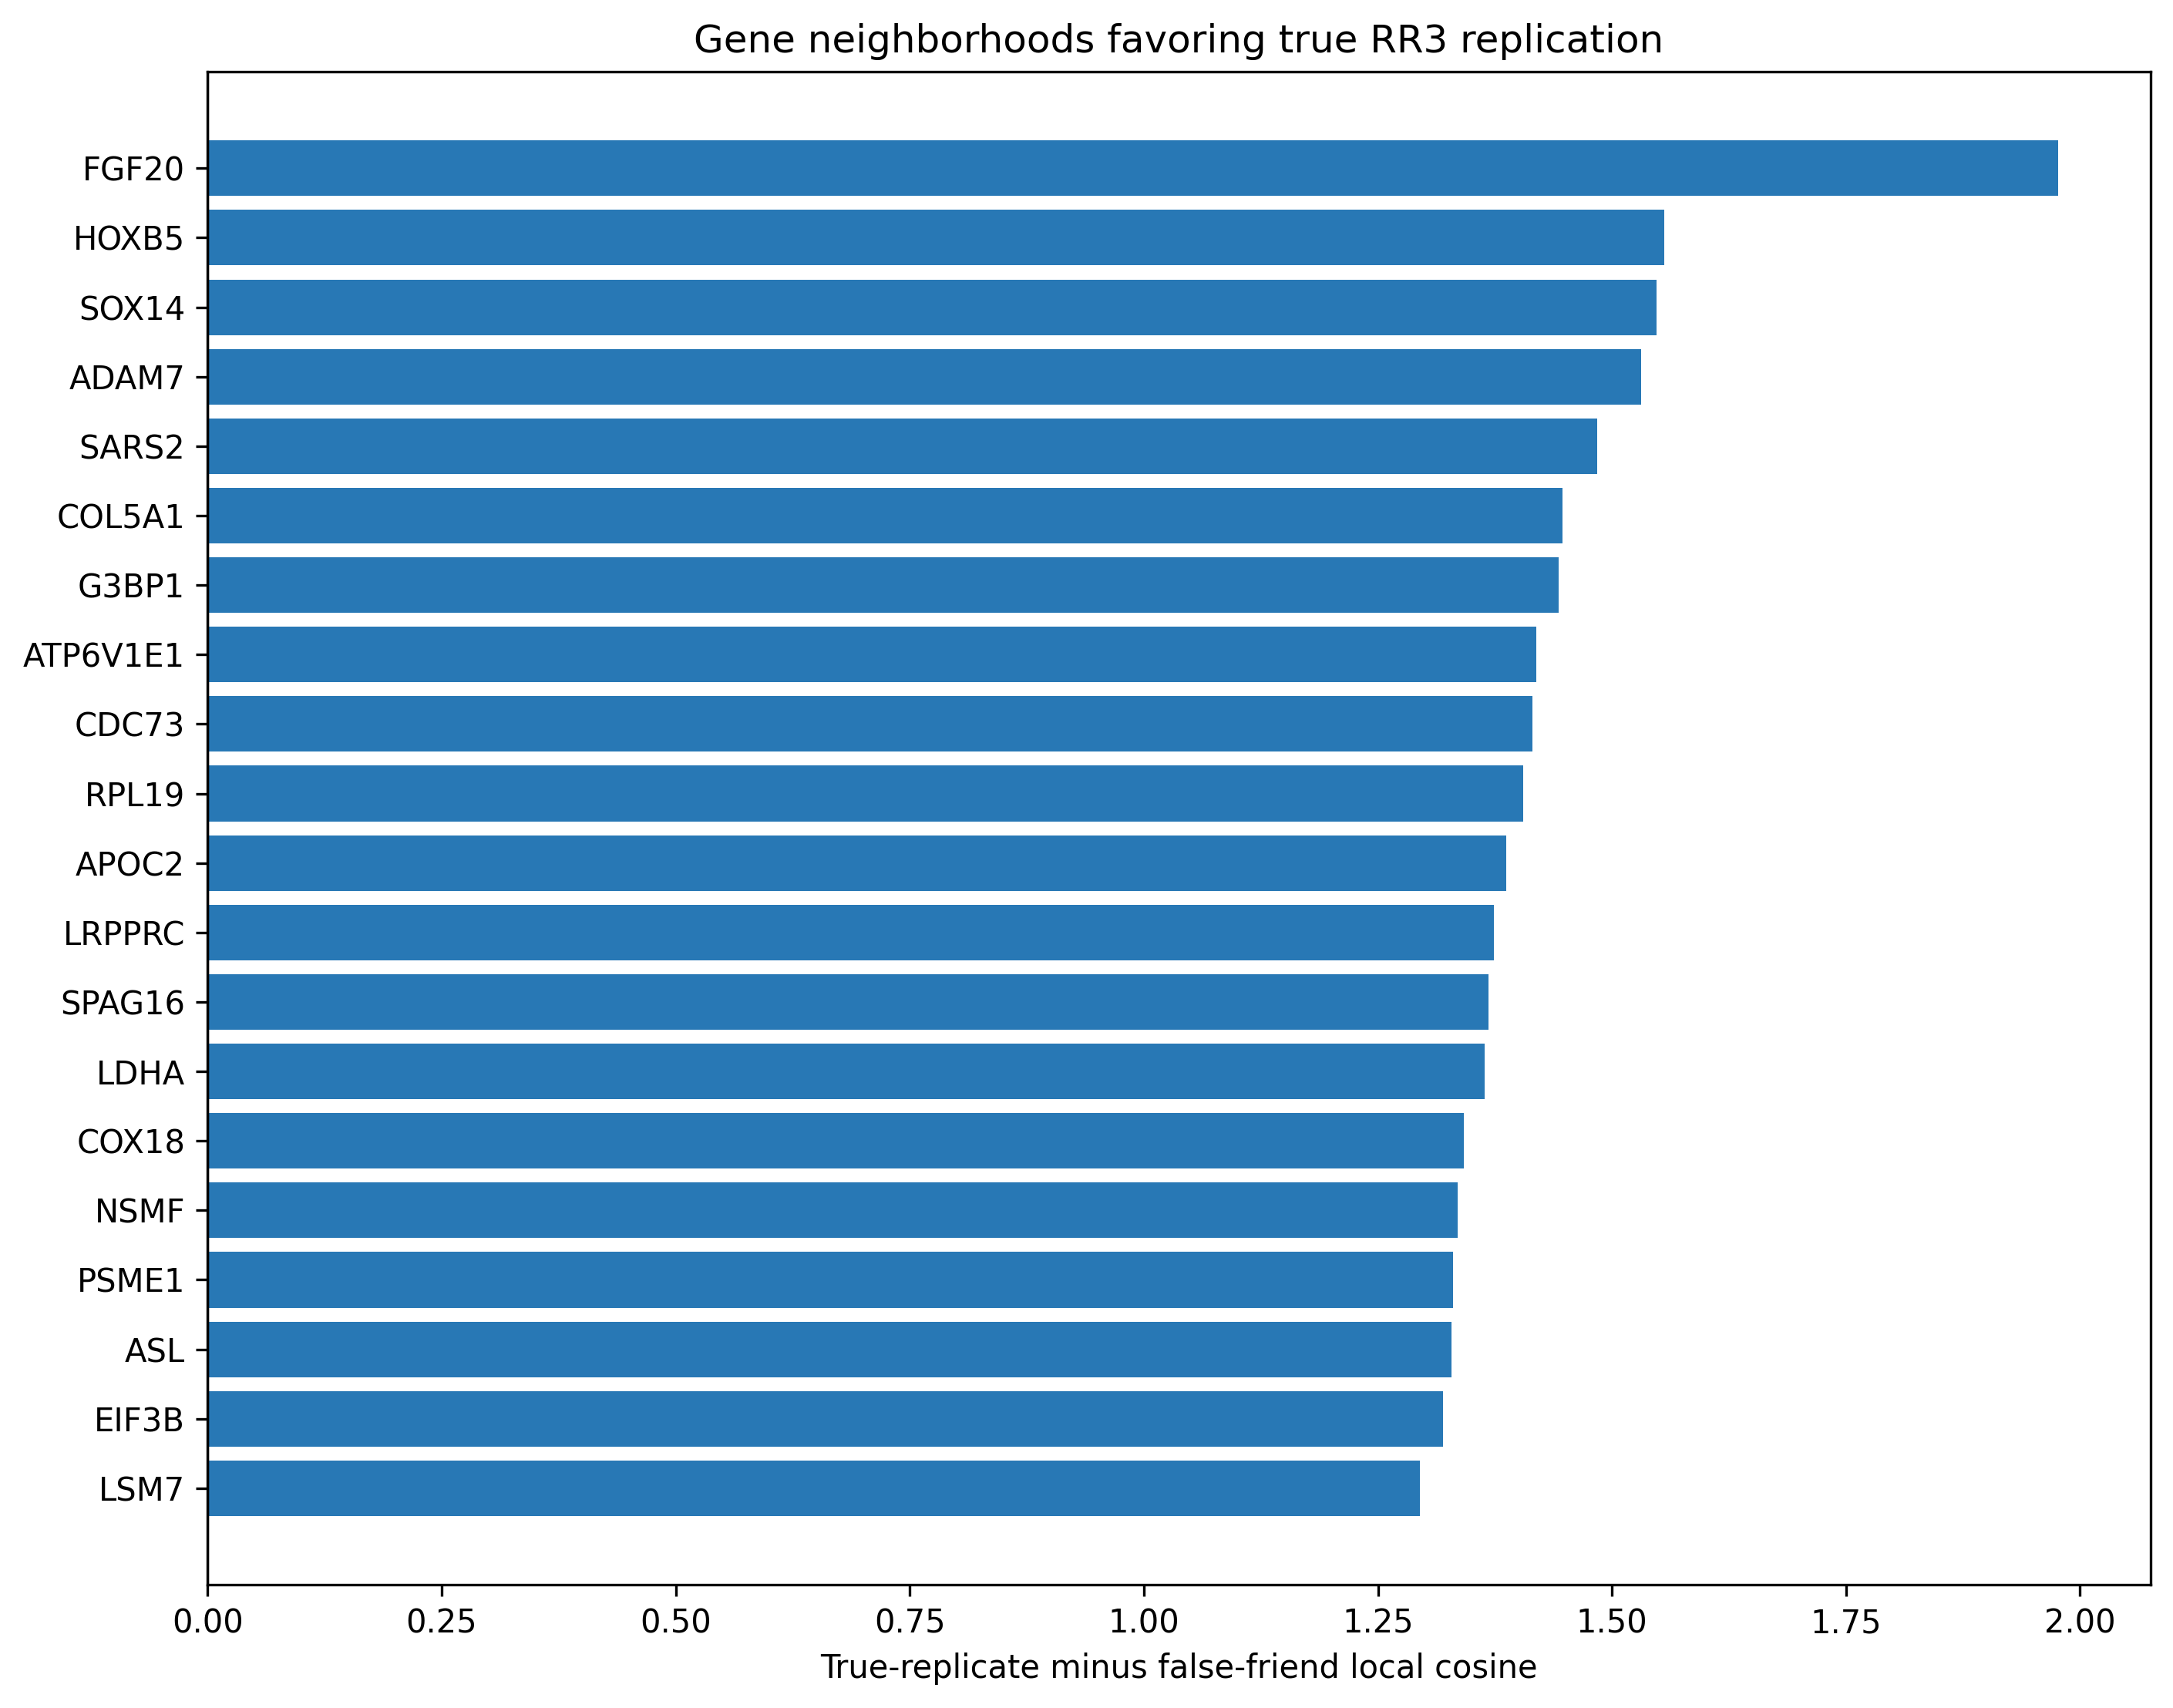

In [4]:
genes = pd.read_csv(RESULTS / 'top50_discriminative_gene_neighborhoods.csv')
display(genes.head(20).style.format({c: '{:.3f}' for c in genes.columns if 'cosine' in c or 'discrimination' in c}))
display(Image(filename=str(RESULTS / 'figures/top_gene_neighborhoods.png')))

## Biological annotation of the discriminative neighborhoods

The Top-250 diagnostic genes were annotated after ranking, using the exact 15,165-gene vocabulary as the enrichment background. Enrichment is a hypothesis-generating annotation of the genes whose neighborhoods discriminate the cases; it does not turn graph edges into regulatory claims.

In [5]:
enrichment = pd.read_csv(RESULTS / 'top250_neighborhood_enrichment.csv')
display(enrichment.head(15).style.format({'p_value': '{:.2e}', 'fdr': '{:.3g}'}))

,term,overlap,set_size,p_value,fdr
0,Reactome: NR1H2 & NR1H3 Regulate Gene Expression Linked to Lipogenesis,4,7,2.43e-06,0.00571
1,Reactome: NR1H2 and NR1H3-mediated Signaling,7,42,5.02e-06,0.0059
2,"Reactome: Formation of the Ternary Complex, and Subsequently, the 43S Complex",6,35,2.05e-05,0.0115
3,Reactome: Regulation of Cholesterol Biosynthesis by SREBP (SREBF),7,52,2.16e-05,0.0115
4,Reactome: SARS-CoV-1 Modulates Host Translation Machinery,5,22,2.45e-05,0.0115
5,Reactome: Translation Initiation Complex Formation,6,40,4.54e-05,0.0153
6,"Reactome: mRNA Activation Upon Binding of the Cap-Binding Complex and eIFs, and Subsequent Binding to 43S",6,40,4.54e-05,0.0153
7,Reactome: Ribosomal Scanning and Start Codon Recognition,6,41,5.24e-05,0.0154
8,Hallmark: Bile Acid Metabolism,9,106,6.36e-05,0.0166
9,Reactome: Metabolism of Steroids,10,133,7.08e-05,0.0167


## What BridgeRNA contributes—and what it does not

**Showcase result.** A single global embedding produces a false-friend ordering, whereas the frozen contextual graph distinguishes both true RR3 technical remeasurements from that unrelated pair. Gene-level localization highlights neighborhoods involving lipogenic/cholesterol, bile-acid/fatty-acid, nuclear-receptor, and translation-related programs.

**Interpretation.** BridgeRNA's contextual tokens preserve information about *how genes are organized relative to one another* that global averaging can erase. This offers a scientist-facing route from a sample-level similarity anomaly to specific gene neighborhoods and testable biological programs.

**Limits.** Raw expression, PCA, and Hallmark module pooling also avoid this particular false ordering, so this is not a claim that graphs uniquely outperform conventional representations. RR1 remains a cross-protocol reproducibility failure. The cohort is small, graph scores are representation-specific, and contextual proximity does not establish physical interaction, regulation, or causality.